# «Вайбкодинг убивает джунов?»: сборка результатов

Автор: Калошкина Светлана.

Этот ноутбук последовательно вызывает все скрипты `src/` и показывает
итоговые таблицы и рисунки, которые вошли в записку (`report/`).
Полная инструкция по воспроизведению приведена в `README.md`.

In [1]:
import subprocess, sys, time
from pathlib import Path

ROOT = Path.cwd()
scripts = [
    "src/00_download.py",
    "src/01_prepare.py",
    "src/02_descriptive.py",
    "src/03_did.py",
    "src/04_robustness.py",
]

t0 = time.time()
for s in scripts:
    print(f"\n=== {s} ===")
    result = subprocess.run(
        [sys.executable, s], check=True,
        capture_output=True, text=True, encoding="utf-8",
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
print(f"\nПолный прогон занял {time.time() - t0:.1f} с.")


=== src/00_download.py ===
Файл уже существует, повторно не скачиваю: data/raw/vacancies.parquet
Размер: 57.13 МБ
SHA-256: e0ff1d27379c0e2d275fc92025185c0feec9e95677c0e9d9ed0aac0868a97d6f


=== src/01_prepare.py ===


Готово за 2.1 с. Строк: 85086 (ожидалось 85086).
Сохранено: data/processed/analysis.parquet (101.5 МБ)
Флаг jun_j1, N = 49951
Флаг jun_j2, N = 11132
Флаг jun_j3, N = 3331

Кросс-таблица J1 x J3 (доли от J1):
jun_j3     False     True 
jun_j1                    
False   0.998634  0.001366
True    0.934276  0.065724

Роли без группы: (должно быть пусто)
<ArrowStringArray>
[]
Length: 0, dtype: str

Распределение по группам ролей:
role_group
noncode       43184
code          27332
analytics     13290
leadership     1280
Name: count, dtype: int64

В основной выборке (код+не-код) 70516 вакансий, из них 151 с пустым employer_id; они исключаются из всех моделей с кластеризацией/FE по работодателю (Т5-Т7), рабочая выборка моделей: 70365.


=== src/02_descriptive.py ===


Т1 готова:
       n_vacancies  n_employers  n_roles  n_regions  share_moscow
year                                                            
2023        18017         9272       21        618      0.400566
2024        26414        11663       21        919      0.403233
2025        29690        13825       21        780      0.387235
2026        10965         6267       21        502      0.389512 

Т2 готова:
                               definition      n  share_of_sample
0           J1 (noExperience + 1-3 года)  49951         0.587065
1               J2 (только noExperience)  11132         0.130832
2  J3 (junior/младший/стажёр в названии)   3331         0.039149 

Т2b (пересечения):
                            group      n  share_with_jun_title_j3
0              J2 (noExperience)  11132                 0.168254
1  between1And3 (не входит в J2)  38819                 0.036322 

Р1 сохранён

Т3 (shift-share):
  y_before: 0.59841
  y_after: 0.57294
  total_change: -0.02547
  within_r

=== J1 (jun_j1) ===
  manual_4means                coef=-0.0239  se=n/a  n=70365
  ols_no_fe                    coef=-0.0239  se=0.0105  n=70365
  ols_fe_role_month            coef=-0.0287  se=0.0098  n=70365
  ols_fe_continuous_exposure   coef=-0.0069  se=0.0029  n=70365
=== J2 (jun_j2) ===
  manual_4means                coef=+0.0279  se=n/a  n=70365
  ols_no_fe                    coef=+0.0279  se=0.0208  n=70365
  ols_fe_role_month            coef=+0.0186  se=0.0159  n=70365
  ols_fe_continuous_exposure   coef=+0.0049  se=0.0057  n=70365
=== J3 (jun_j3) ===
  manual_4means                coef=+0.0092  se=n/a  n=70365
  ols_no_fe                    coef=+0.0092  se=0.0043  n=70365
  ols_fe_role_month            coef=+0.0100  se=0.0043  n=70365
  ols_fe_continuous_exposure   coef=+0.0017  se=0.0011  n=70365

Т5 сохранена: output/tables/T5_did_summary.csv
Р3 сохранён

Основная DiD-модель (Т5, Р3) завершена за 7.6 с.


=== src/04_robustness.py ===


Событийное исследование (Р4)...
  Р4 сохранён

Проверки устойчивости (Т6)...
                                                               check      coef       se  p_value  n_obs
         основная спецификация (2025-02, код vs не-код, вся выборка) -0.028669 0.009759 0.003307  70365
                            плацебо: дата 2024-02, выборка < 2025-01 -0.008690 0.010767 0.419632  36779
                                              дата отсечки = 2024-11 -0.032404 0.009257 0.000464  70365
                                              дата отсечки = 2025-02 -0.028669 0.009759 0.003307  70365
                                              дата отсечки = 2025-06 -0.024638 0.010620 0.020344  70365
                             состав: тестировщики -> в группу не-код -0.019914 0.009596 0.037965  70365
                                состав: аналитики/DS -> в группу код -0.031727 0.009367 0.000706  83625
                          регионы: без Алматы/Минска/Ташкента/Астаны -0.026051 0.010402 0.0

## Т1. Описание выборки по годам

In [2]:
import pandas as pd
pd.read_csv("output/tables/T1_sample.csv", index_col=0)

,n_vacancies,n_employers,n_roles,n_regions,share_moscow
year,,,,,
2023,18017,9272,21,618,0.400566
2024,26414,11663,21,919,0.403233
2025,29690,13825,21,780,0.387235
2026,10965,6267,21,502,0.389512


## Т2. Три определения джуна и пересечения

In [3]:
display(pd.read_csv("output/tables/T2_jun_definitions.csv"))
display(pd.read_csv("output/tables/T2b_jun_overlap.csv"))

,definition,n,share_of_sample
0,J1 (noExperience + 1-3 года),49951,0.587065
1,J2 (только noExperience),11132,0.130832
2,J3 (junior/младший/стажёр в названии),3331,0.039149


,group,n,share_with_jun_title_j3
0,J2 (noExperience),11132,0.168254
1,between1And3 (не входит в J2),38819,0.036322


## Р1. Доля джунов по месяцам, три определения

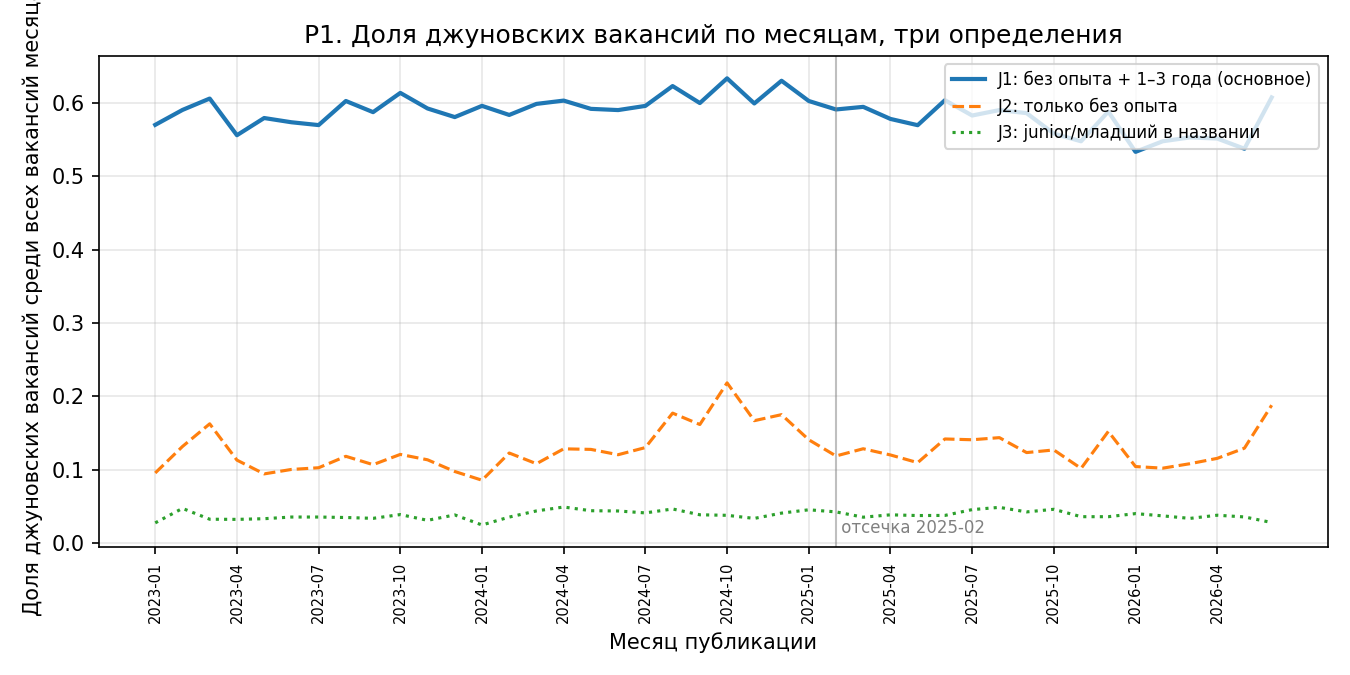

In [4]:
from IPython.display import Image
Image("output/figures/R1_jun_share_by_month.png")

## Т3. Shift-share разложение

In [5]:
pd.read_csv("output/tables/T3_shift_share.csv", index_col=0)

,value
y_before,5.984105e-01
y_after,5.729400e-01
total_change,-2.547048e-02
within_role_component,-2.679819e-02
between_role_component,1.327710e-03
sum_components,-2.547048e-02
residual,-5.204170e-17


## Т4. Доля джунов по ролям и годам

In [6]:
pd.read_csv("output/tables/T4_jun_by_role_year.csv", index_col=0)

,share_2023,share_2024,share_2025,share_2026,n_2023,n_2024,n_2025,n_2026
professional_roles_clean,,,,,,,,
"BI-аналитик, аналитик данных",0.617801,0.608586,0.587234,0.564912,191,396,705,285
DevOps-инженер,0.436170,0.366738,0.338983,0.292490,282,469,649,253
Аналитик,0.649412,0.687471,0.636605,0.578275,1700,2179,1885,626
Бизнес-аналитик,0.564987,0.548341,0.558824,0.489164,377,693,816,323
Гейм-дизайнер,0.489796,0.544118,0.605839,0.707317,49,68,137,41
Дата-сайентист,0.405797,0.460227,0.356383,0.333333,69,176,376,198
"Дизайнер, художник",0.702259,0.718134,0.724843,0.713884,1461,2079,3031,1066
Директор по информационным технологиям (CIO),0.058824,0.122222,0.140351,0.173077,68,90,114,52
Менеджер продукта,0.509554,0.538213,0.490617,0.398182,628,929,1119,550


## Р2. Доля вакансий с упоминанием ИИ-инструментов по месяцам

Помесячные цифры сохранены отдельно (`R2_ai_mention_by_month.csv`), не
только на графике; раздел 1.4 записки сверяется именно с этим файлом.

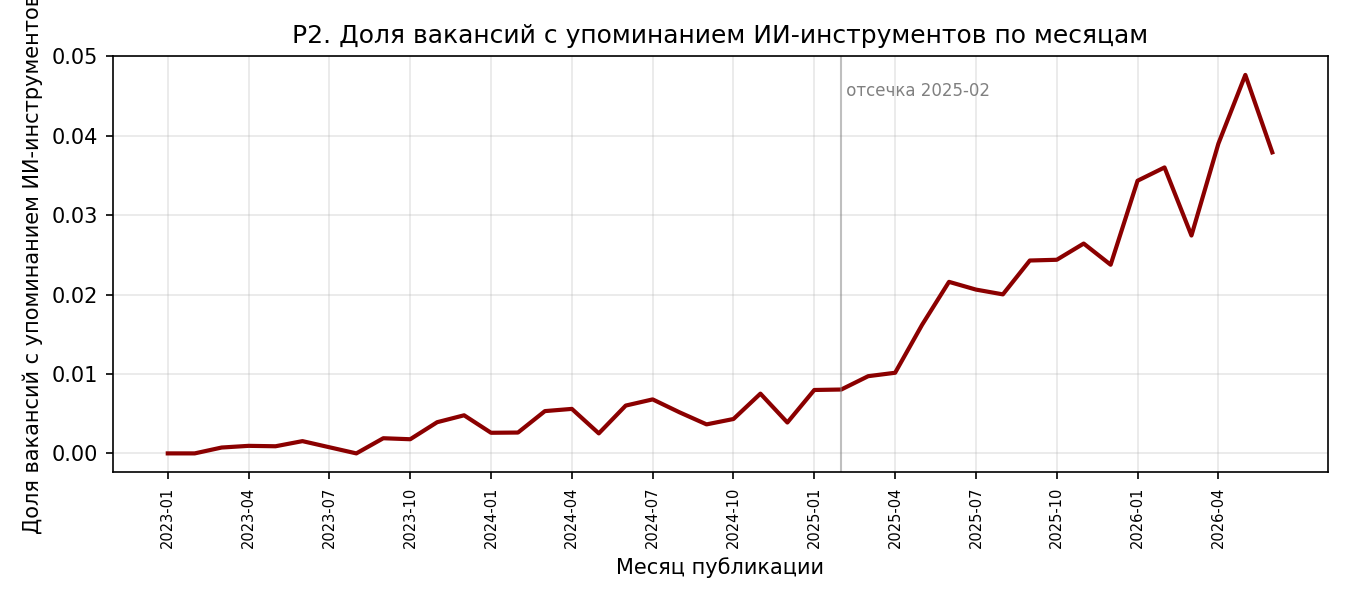

,published_month,ai_mention_share
0,2023-01,0.000000
1,2023-02,0.000000
2,2023-03,0.000739
3,2023-04,0.000951
4,2023-05,0.000898
5,2023-06,0.001544
6,2023-07,0.000772
7,2023-08,0.000000
8,2023-09,0.001910
9,2023-10,0.001783


In [7]:
from IPython.display import Image
display(Image("output/figures/R2_ai_mention_by_month.png"))
pd.read_csv("output/tables/R2_ai_mention_by_month.csv")

## Р3. Код-роли против не-код, по кварталам

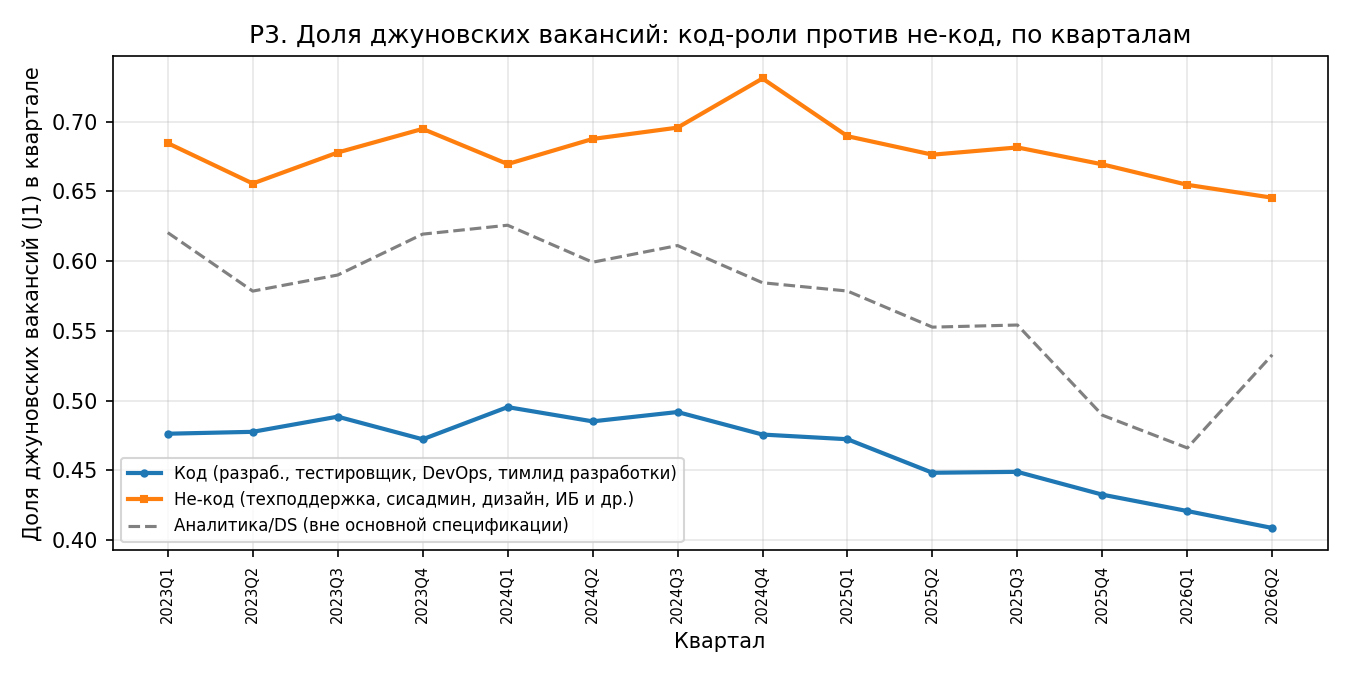

In [8]:
Image("output/figures/R3_jun_share_code_vs_noncode.png")

## Т5. DiD: ручной расчёт, регрессии, три определения джуна

In [9]:
pd.read_csv("output/tables/T5_did_summary.csv")

,definition,spec,coef,se,p_value,ci_low,ci_high,n_obs,note,term
0,J1,manual_4means,-0.023920,NaN,NaN,NaN,NaN,70365,code: 0.484->0.439 (-0.045); noncode: 0.692->0...,NaN
1,J1,ols_no_fe,-0.023920,0.010541,0.023253,-0.044581,-0.003260,70365,должен совпасть с manual_4means; совпадение: True,code:post_i
2,J1,ols_fe_role_month,-0.028669,0.009759,0.003307,-0.047797,-0.009541,70365,"FE роли+месяца, кластеры по работодателю",code:post_i
3,J1,ols_fe_continuous_exposure,-0.006928,0.002855,0.015222,-0.012523,-0.001333,70365,коэфф. на 1 п.п. экспозиции роли к ИИ,exposure_pp:post_i
4,J2,manual_4means,0.027936,NaN,NaN,NaN,NaN,70365,code: 0.075->0.076 (+0.001); noncode: 0.193->0...,NaN
5,J2,ols_no_fe,0.027936,0.020819,0.179649,-0.012869,0.068741,70365,должен совпасть с manual_4means; совпадение: True,code:post_i
6,J2,ols_fe_role_month,0.018581,0.015932,0.243502,-0.012645,0.049808,70365,"FE роли+месяца, кластеры по работодателю",code:post_i
7,J2,ols_fe_continuous_exposure,0.004925,0.005669,0.385013,-0.006187,0.016037,70365,коэфф. на 1 п.п. экспозиции роли к ИИ,exposure_pp:post_i
8,J3,manual_4means,0.009176,NaN,NaN,NaN,NaN,70365,code: 0.057->0.066 (+0.008); noncode: 0.022->0...,NaN
9,J3,ols_no_fe,0.009176,0.004262,0.031300,0.000824,0.017529,70365,должен совпасть с manual_4means; совпадение: True,code:post_i


## Р4. Событийное исследование

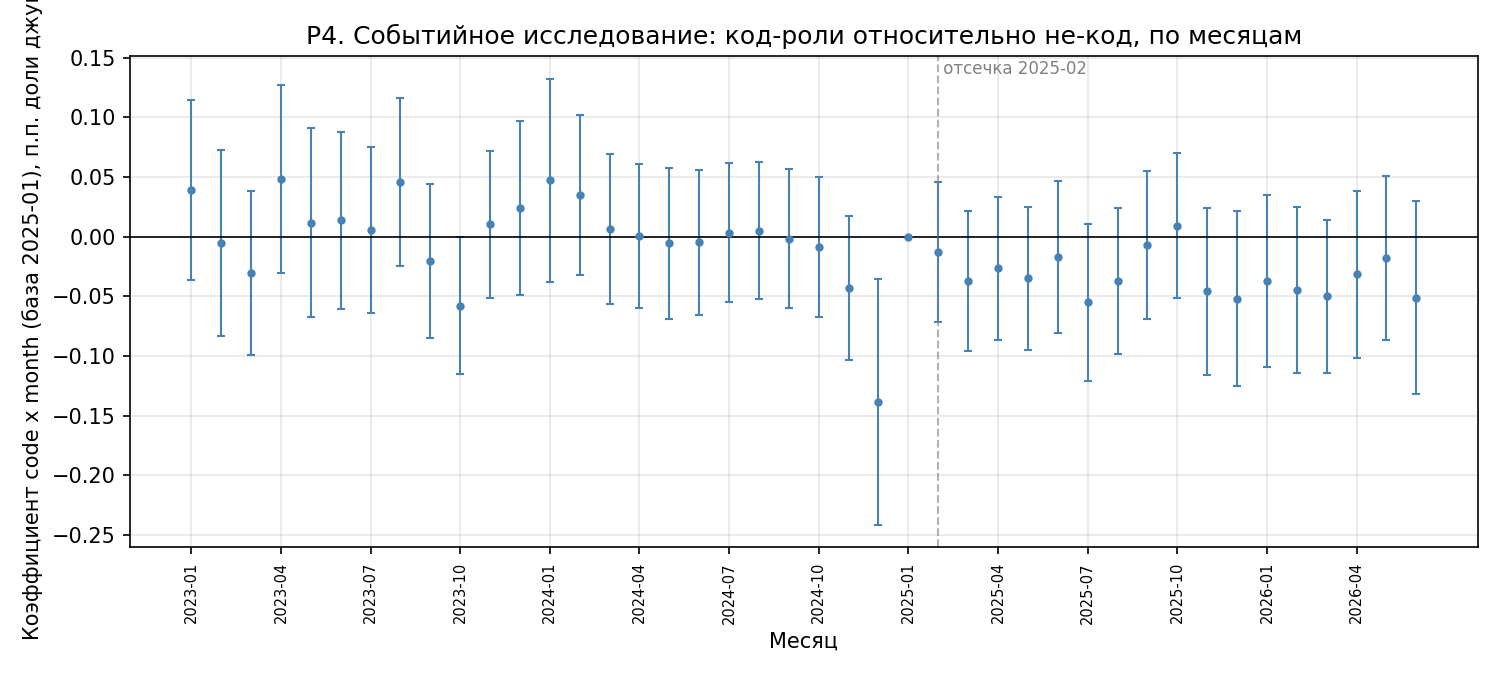

In [10]:
Image("output/figures/R4_event_study.png")

## Т6. Плацебо и проверки устойчивости

27 строк: 1 базовая спецификация, 22 проверки устойчивости (сохраняют знак
все 22), 2 строки декомпозиции по сегментам опыта (результат, не проверка)
и 2 проверки на допериодный тренд; см. записку, раздел 4, абзац
«Параллельность трендов»: это ключевая оговорка к основному результату.

In [11]:
pd.read_csv("output/tables/T6_robustness.csv")

,check,coef,se,p_value,ci_low,ci_high,n_obs
0,"основная спецификация (2025-02, код vs не-код,...",-0.028669,0.009759,0.003307,-0.047797,-0.009541,70365
1,"плацебо: дата 2024-02, выборка < 2025-01",-0.008690,0.010767,0.419632,-0.029793,0.012413,36779
2,дата отсечки = 2024-11,-0.032404,0.009257,0.000464,-0.050547,-0.014261,70365
3,дата отсечки = 2025-02,-0.028669,0.009759,0.003307,-0.047797,-0.009541,70365
4,дата отсечки = 2025-06,-0.024638,0.010620,0.020344,-0.045454,-0.003823,70365
5,состав: тестировщики -> в группу не-код,-0.019914,0.009596,0.037965,-0.038722,-0.001106,70365
6,состав: аналитики/DS -> в группу код,-0.031727,0.009367,0.000706,-0.050086,-0.013368,83625
7,регионы: без Алматы/Минска/Ташкента/Астаны,-0.026051,0.010402,0.012263,-0.046438,-0.005664,64236
8,только Москва и Санкт-Петербург,-0.042010,0.012513,0.000787,-0.066536,-0.017484,33060
9,без роли: DevOps-инженер,-0.026813,0.009930,0.006933,-0.046276,-0.007349,68713


## Т7. Модель с фиксированными эффектами работодателя + наблюдение по фирмам

In [12]:
display(pd.read_csv("output/tables/T7_employer_fe.csv", index_col=0))
display(pd.read_csv("output/tables/T7b_ai_adopters_observation.csv"))

,value
coef,-0.049896
se,0.013989
p_value,0.000361
ci_low,-0.077314
ci_high,-0.022477
n_obs,42312.000000
n_employers,5204.000000
se_uncorrected,0.013099


,group,n_employers,jun_share_before,jun_share_after,change
0,начали упоминать ИИ после отсечки (не упоминал...,185,0.486112,0.420212,-0.065899
1,никогда не упоминали ИИ,4973,0.617163,0.581462,-0.035701
